In [17]:
# TOP OF NOTEBOOK — before any other imports
import os
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=14"

In [18]:
# Now import everything else
import jax
import hssm
import arviz as az
import pandas as pd
import numpy as np

In [19]:
import jax
print(f"Devices available: {len(jax.devices())}")
print(jax.devices())

Devices available: 14
[CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11), CpuDevice(id=12), CpuDevice(id=13)]


In [20]:
# EEG FORSØG
df_binaural_eeg = pd.read_csv("data/eegbinaural_ses1_20260508_092645.csv")
df_control_eeg  = pd.read_csv("data/eegcontrol_ses1_20260508_084700.csv")

df_binaural_eeg["participant_id"] = "eeg"
df_control_eeg["participant_id"] = "eeg"

df_binaural_eeg["condition"] = "binaural"
df_control_eeg["condition"]  = "control"

# DAVID
df_binaural_david = pd.read_csv("data/David_binarual_ses1_20260514_172049.csv")
df_control_david  = pd.read_csv("data/David_control_ses1_20260526_211923.csv")

df_binaural_david["participant_id"] = "david"
df_control_david["participant_id"] = "david"

df_binaural_david["condition"] = "binaural"
df_control_david["condition"]  = "control"

# TUT
df_binaural_tut = pd.read_csv("data/TUT_ses1_20260523_130540_BINAURAL.csv")
df_control_tut  = pd.read_csv("data/TUT_ses1_20260524_225147.csv")

df_binaural_tut["participant_id"] = "tut"
df_control_tut["participant_id"] = "tut"

df_binaural_tut["condition"] = "binaural"
df_control_tut["condition"]  = "control"

# CLA
df_binaural_cla = pd.read_csv("data/CLA_binaural_ses1_20260525_194912.csv")
df_control_cla  = pd.read_csv("data/CLA_ses1_20260525_184531.csv")

df_binaural_cla["participant_id"] = "cla"
df_control_cla["participant_id"] = "cla"

df_binaural_cla["condition"] = "binaural"
df_control_cla["condition"]  = "control"

# JOHAN
df_binaural_johan = pd.read_csv("data/Johan_binarual_ses1_20260524_221900.csv")
df_control_johan  = pd.read_csv("data/Johan_control_ses1_20260514_132716.csv")

df_binaural_johan["participant_id"] = "johan"
df_control_johan["participant_id"] = "johan"

df_binaural_johan["condition"] = "binaural"
df_control_johan["condition"]  = "control"

# SAMLE ALLE DATAFRAMES
raw_df = pd.concat([
    df_binaural_eeg,
    df_control_eeg,
    df_binaural_david,
    df_control_david,
    df_binaural_tut,
    df_control_tut,
    df_binaural_cla,
    df_control_cla,
    df_binaural_johan,
    df_control_johan
], ignore_index=True)

In [21]:
raw_df = raw_df.rename(columns={"reaction_time": "rt"})
raw_df = raw_df.loc[raw_df["is_practice"]==0]
raw_df = raw_df.dropna()
raw_df['response'] = raw_df['response'].map({'left': -1, 'right': 1})
raw_df = raw_df[raw_df["rt"] > 0.15]

In [22]:
raw_df

,participant_id,session,task_type,trial_number,block_number,is_practice,coherence,direction,trial_start_trigger,stimulus_trigger,response_trigger,feedback_trigger,response,accuracy,rt,stimulus_onset_time,response_time,trial_duration,condition
14,eeg,1,binaural,1,1,0,0.25,left,20,126,1.0,10.0,-1,1.0,0.603562,1668.981905,1669.585467,0.617085,binaural
15,eeg,1,binaural,2,1,0,0.06,left,20,107,2.0,11.0,1,0.0,0.916603,1670.465332,1671.381935,0.917347,binaural
16,eeg,1,binaural,3,1,0,0.12,left,20,113,1.0,10.0,-1,1.0,0.854370,1672.348378,1673.202749,0.866941,binaural
17,eeg,1,binaural,4,1,0,0.12,left,20,113,1.0,10.0,-1,1.0,0.784808,1674.281806,1675.066614,0.785692,binaural
18,eeg,1,binaural,5,1,0,0.06,left,20,107,1.0,10.0,-1,1.0,1.465663,1676.115044,1677.580708,1.466204,binaural
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4935,johan,1,control,476,4,0,0.25,right,20,127,2.0,10.0,1,1.0,0.567529,2376.505837,2377.073367,0.568089,control
4936,johan,1,control,477,4,0,0.50,right,20,152,2.0,10.0,1,1.0,0.836325,2378.005280,2378.841604,0.837184,control
4937,johan,1,control,478,4,0,0.25,left,20,126,1.0,10.0,-1,1.0,0.479891,2379.678351,2380.158242,0.483066,control
4938,johan,1,control,479,4,0,0.06,left,20,107,1.0,10.0,-1,1.0,1.429770,2381.195372,2382.625142,1.430880,control


In [23]:
v_true = 0.5
a_true = 1.5
z_true = 0.5
t_true = 0.5

param_dict_init = dict(
    v=v_true,
    a=a_true,
    z=z_true,
    t=t_true,
)

In [24]:
d_tut = raw_df[raw_df["participant_id"] == "tut"]
d_eeg = raw_df[raw_df["participant_id"] == "eeg"]
d_david = raw_df[raw_df["participant_id"] == "david"]
d_cla = raw_df[raw_df["participant_id"] == "cla"]
d_johan = raw_df[raw_df["participant_id"] == "johan"]

In [25]:
from scipy.stats import zscore
raw_df["coherence_z"] = zscore(raw_df["coherence"])

In [14]:
import os
os.makedirs("figures", exist_ok=True)

In [ ]:
import jax
print(jax.devices())  # shows "gpu" if available, otherwise "cpu"
import os
print(os.cpu_count())

[CpuDevice(id=0)]
14


In [38]:
print(raw_df["direction"].unique())
print(raw_df[["direction", "response", "accuracy"]].head(10))

['left' 'right']
   direction  response  accuracy
14      left        -1       1.0
15      left         1       0.0
16      left        -1       1.0
17      left        -1       1.0
18      left        -1       1.0
19     right         1       1.0
20      left        -1       1.0
21      left         1       0.0
22     right         1       1.0
23     right        -1       0.0


In [39]:
# Map direction to -1/1 to match response coding
raw_df["direction_coded"] = raw_df["direction"].map({"left": -1, "right": 1})

# Verify — should match accuracy perfectly
raw_df["response_correct"] = (raw_df["response"] == raw_df["direction_coded"]).astype(int)
print((raw_df["response_correct"] == raw_df["accuracy"]).all())  # must be True

True


In [40]:
# HSSM needs 0/1 where 1 = correct boundary
raw_df["response_hssm"] = raw_df["response_correct"]

# Verify distribution
print(raw_df.groupby("coherence")["response_hssm"].mean())
# Should increase with coherence — 0.60 at 0.0, ~0.98 at 0.50

coherence
0.00    0.601030
0.03    0.728093
0.06    0.799233
0.12    0.905542
0.25    0.969811
0.50    0.982500
Name: response_hssm, dtype: float64


In [42]:
# Map direction to -1/1 to match response coding
raw_df["direction_coded"] = raw_df["direction"].map({"left": -1, "right": 1})

# Verify matches accuracy
raw_df["response_correct"] = (raw_df["response"] == raw_df["direction_coded"]).astype(int)
print((raw_df["response_correct"] == raw_df["accuracy"]).all())  # must be True

# Recode to -1/1 where 1 = correct, -1 = incorrect
raw_df["response_hssm"] = raw_df["response_correct"].map({0: -1, 1: 1})

# Verify — mean should increase with coherence
print(raw_df.groupby("coherence")["response_hssm"].mean())
# Expected:
# 0.00    ~0.20   (60% correct → 20% when mapped to -1/1 scale)
# 0.50    ~0.96

True
coherence
0.00    0.202059
0.03    0.456186
0.06    0.598465
0.12    0.811083
0.25    0.939623
0.50    0.965000
Name: response_hssm, dtype: float64


In [43]:
raw_df_hssm = raw_df.copy()
raw_df_hssm["response"] = raw_df_hssm["response_hssm"]

model_all = hssm.HSSM(
    data=raw_df_hssm,
    model="ddm",
    include=[
        {"name": "v", "formula": "v ~ 1 + condition + coherence_z + (1|participant_id)"},
        {"name": "a", "formula": "a ~ 1 + condition + (1|participant_id)"},
    ]
)

idata_all = model_all.sample(
    sampler="numpyro",
    chains=4,
    draws=1000,
    tune=1000,
    target_accept=0.9,
    chain_method="parallel"
)

az.summary(idata_all)

Model initialized successfully.
Using default initvals. 



Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:07<?, ?it/s]



Running chain 0:   5%|▌         | 100/2000 [04:41<1:26:45,  2.74s/it]

Running chain 0:  10%|█         | 200/2000 [07:03<58:58,  1.97s/it]  


Running chain 0:  15%|█▌        | 300/2000 [09:10<46:37,  1.65s/it]



Running chain 0:  20%|██        | 400/2000 [10:55<37:39,  1.41s/it]


Running chain 0:  25%|██▌       | 500/2000 [13:43<37:44,  1.51s/it]




Running chain 0:  30%|███       | 600/2000 [16:05<34:28,  1.48s/it]


Running chain 0:  35%|███▌      | 700/2000 [18:23<31:18,  1.44s/it]



Running chain 0:  40%|████      | 800/2000 [20:40<28:27,  1.42s/it]


Running chain 0:  45%|████▌     | 900/2000 [22:38<24:42,  1.35s/it]


Running chain 0:  50%|█████     | 1000/2000 [25:25<24:05,  1.45s/it]


Running chain 0:  55%|█████▌    | 1100/2000 [26:52<19:03,  1.27s/it]


Running chain 0:  60%|██████    | 1200/2000 [28:25<15:34,  1.17s/it]

Running chain 0:  65%|██████▌ 

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
v_1|participant_id[cla],0.129,0.224,-0.276,0.578,0.006,0.005,1348.0,1748.0,1.00
v_1|participant_id[david],-0.282,0.220,-0.710,0.128,0.006,0.005,1321.0,1509.0,1.00
v_1|participant_id[eeg],0.174,0.222,-0.243,0.619,0.006,0.005,1335.0,1502.0,1.00
v_1|participant_id[johan],-0.689,0.219,-1.086,-0.250,0.006,0.005,1317.0,1645.0,1.00
v_1|participant_id[tut],0.684,0.226,0.223,1.091,0.006,0.005,1393.0,1526.0,1.00
z,0.490,0.007,0.477,0.503,0.000,0.000,4466.0,2889.0,1.00
v_coherence_z,0.966,0.029,0.913,1.023,0.000,0.000,4897.0,2764.0,1.00
v_1|participant_id_offset[cla],0.289,0.468,-0.624,1.140,0.013,0.009,1367.0,1566.0,1.00
v_1|participant_id_offset[david],-0.633,0.476,-1.512,0.291,0.013,0.009,1376.0,1585.0,1.00
v_1|participant_id_offset[eeg],0.390,0.468,-0.514,1.291,0.013,0.009,1353.0,1537.0,1.00


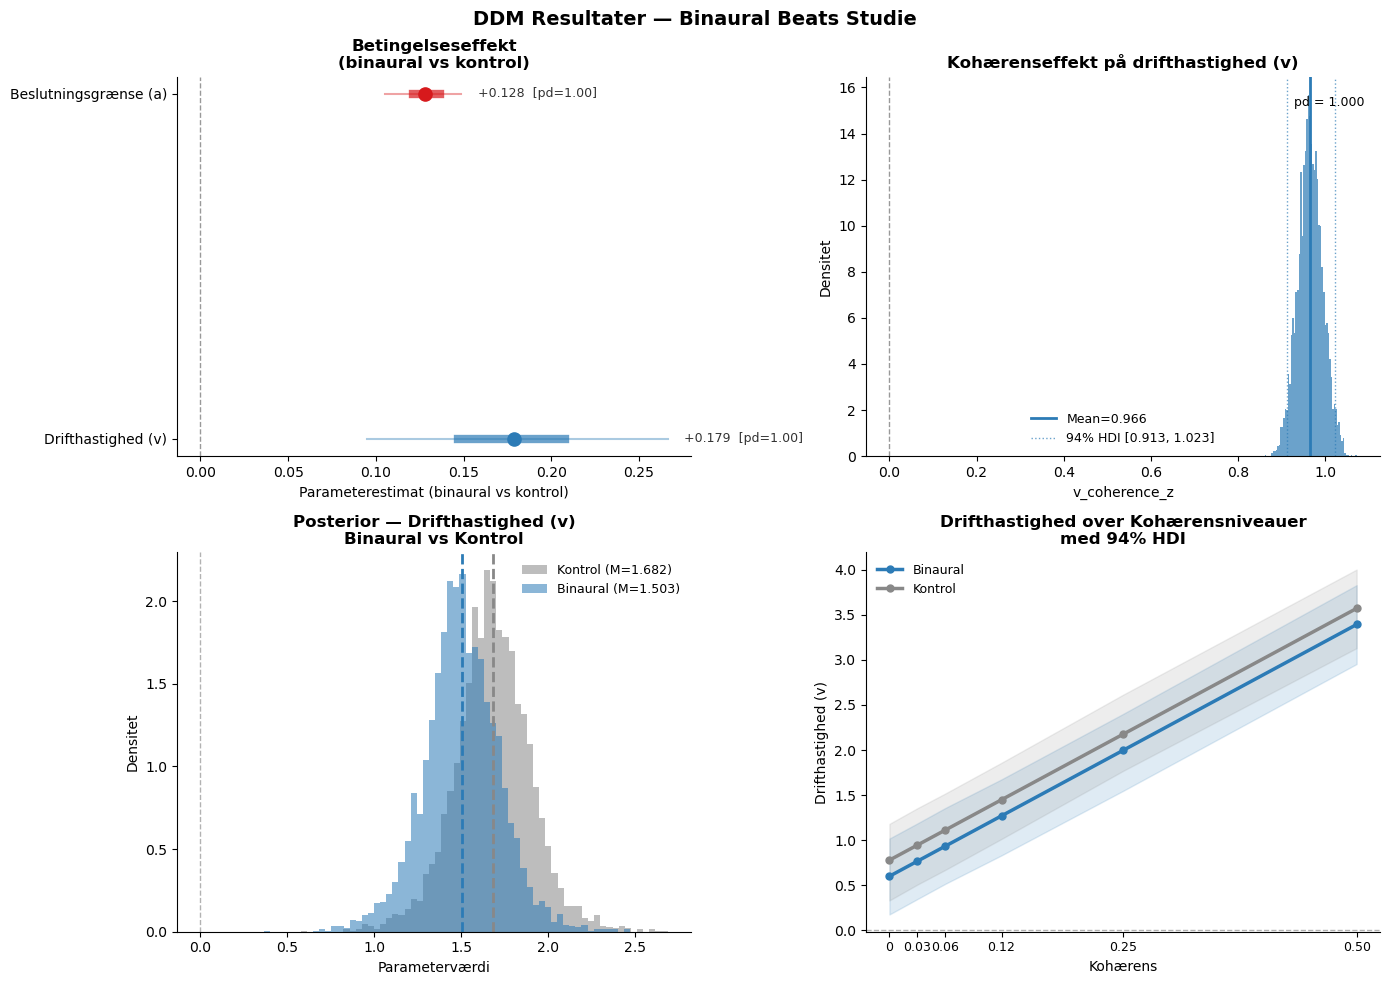

In [49]:
def plot_ddm_results(idata, raw_df_hssm):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # ── 1. Forest plot — condition effects ──────────────────────────────
    ax = axes[0, 0]
    condition_vars = ["v_condition", "a_condition"]
    labels = ["Drifthastighed (v)", "Beslutningsgrænse (a)"]
    colors = ["#2c7bb6", "#d7191c"]
    
    for i, (var, label, color) in enumerate(zip(condition_vars, labels, colors)):
        s     = idata.posterior[var].values.flatten()
        mean  = float(s.mean())
        hdi94 = az.hdi(s, hdi_prob=0.94)
        hdi50 = az.hdi(s, hdi_prob=0.50)
        prob_dir = max(np.mean(s > 0), np.mean(s < 0))
        
        ax.plot([hdi94[0], hdi94[1]], [i, i], color=color, linewidth=1.5, alpha=0.4)
        ax.plot([hdi50[0], hdi50[1]], [i, i], color=color, linewidth=6, alpha=0.7)
        ax.scatter(mean, i, color=color, s=90, zorder=5)
        ax.text(hdi94[1] + 0.005, i,
                f"  {mean:+.3f}  [pd={prob_dir:.2f}]",
                va="center", fontsize=9, color="#333")
    
    ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.4)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel("Parameterestimat (binaural vs kontrol)", fontsize=10)
    ax.set_title("Betingelseseffekt\n(binaural vs kontrol)", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    
    # ── 2. Coherence effect on v ─────────────────────────────────────────
    ax = axes[0, 1]
    s     = idata.posterior["v_coherence_z"].values.flatten()
    mean  = float(s.mean())
    hdi94 = az.hdi(s, hdi_prob=0.94)
    prob_dir = max(np.mean(s > 0), np.mean(s < 0))
    
    ax.hist(s, bins=60, density=True, color="#2c7bb6", alpha=0.7, edgecolor="none")
    ax.axvline(mean,     color="#2c7bb6", linewidth=2, label=f"Mean={mean:.3f}")
    ax.axvline(hdi94[0], color="#2c7bb6", linewidth=1, linestyle=":", alpha=0.7)
    ax.axvline(hdi94[1], color="#2c7bb6", linewidth=1, linestyle=":", alpha=0.7,
               label=f"94% HDI [{hdi94[0]:.3f}, {hdi94[1]:.3f}]")
    ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.4)
    ax.text(0.97, 0.95, f"pd = {prob_dir:.3f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9)
    ax.set_title("Kohærenseffekt på drifthastighed (v)", fontweight="bold")
    ax.set_xlabel("v_coherence_z", fontsize=10)
    ax.set_ylabel("Densitet", fontsize=10)
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    
    # ── 3. Posterior distributions — binaural vs control ─────────────────
    ax = axes[1, 0]
    binaural  = idata.posterior["v_Intercept"].values.flatten()
    control = binaural + idata.posterior["v_condition"].values.flatten()
    
    for samples, label, color in [
        (control,  "Kontrol",  "#888888"),
        (binaural, "Binaural", "#2c7bb6"),
    ]:
        mean = float(samples.mean())
        ax.hist(samples, bins=60, density=True, alpha=0.55,
                label=f"{label} (M={mean:.3f})", color=color, edgecolor="none")
        ax.axvline(mean, color=color, linewidth=2, linestyle="--")
    
    ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.3)
    ax.set_title("Posterior — Drifthastighed (v)\nBinaural vs Kontrol", fontweight="bold")
    ax.set_xlabel("Parameterværdi", fontsize=10)
    ax.set_ylabel("Densitet", fontsize=10)
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    
    # ── 4. Coherence regression lines ────────────────────────────────────
    ax = axes[1, 1]
    coh_orig   = np.array([0, 0.03, 0.06, 0.12, 0.25, 0.50])
    coh_z_vals = (coh_orig - raw_df_hssm["coherence"].mean()) / raw_df_hssm["coherence"].std()
    
    for cond_val, label, color in [(0, "Binaural", "#2c7bb6"), (1, "Kontrol", "#888888")]:
        intercept = idata.posterior["v_Intercept"].values.flatten()
        cond_coef = idata.posterior["v_condition"].values.flatten()
        coh_coef  = idata.posterior["v_coherence_z"].values.flatten()
        
        means, lo, hi = [], [], []
        for cz in coh_z_vals:
            predicted = intercept + cond_val * cond_coef + coh_coef * cz
            hdi_vals  = az.hdi(predicted, hdi_prob=0.94)
            means.append(float(predicted.mean()))
            lo.append(float(hdi_vals[0]))
            hi.append(float(hdi_vals[1]))
        
        ax.plot(coh_orig, means, color=color, linewidth=2.5,
                marker="o", markersize=5, label=label)
        ax.fill_between(coh_orig, lo, hi, color=color, alpha=0.15)
    
    ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.3)
    ax.set_xticks(coh_orig)
    ax.set_xticklabels(["0", "0.03", "0.06", "0.12", "0.25", "0.50"], fontsize=9)
    ax.set_xlabel("Kohærens", fontsize=10)
    ax.set_ylabel("Drifthastighed (v)", fontsize=10)
    ax.set_title("Drifthastighed over Kohærensniveauer\nmed 94% HDI", fontweight="bold")
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    
    plt.suptitle("DDM Resultater — Binaural Beats Studie",
                 fontweight="bold", fontsize=14)
    plt.tight_layout()
    plt.savefig("figures/ddm_full_results.pdf", bbox_inches="tight", dpi=300)
    plt.show()

plot_ddm_results(idata_all, raw_df_hssm)

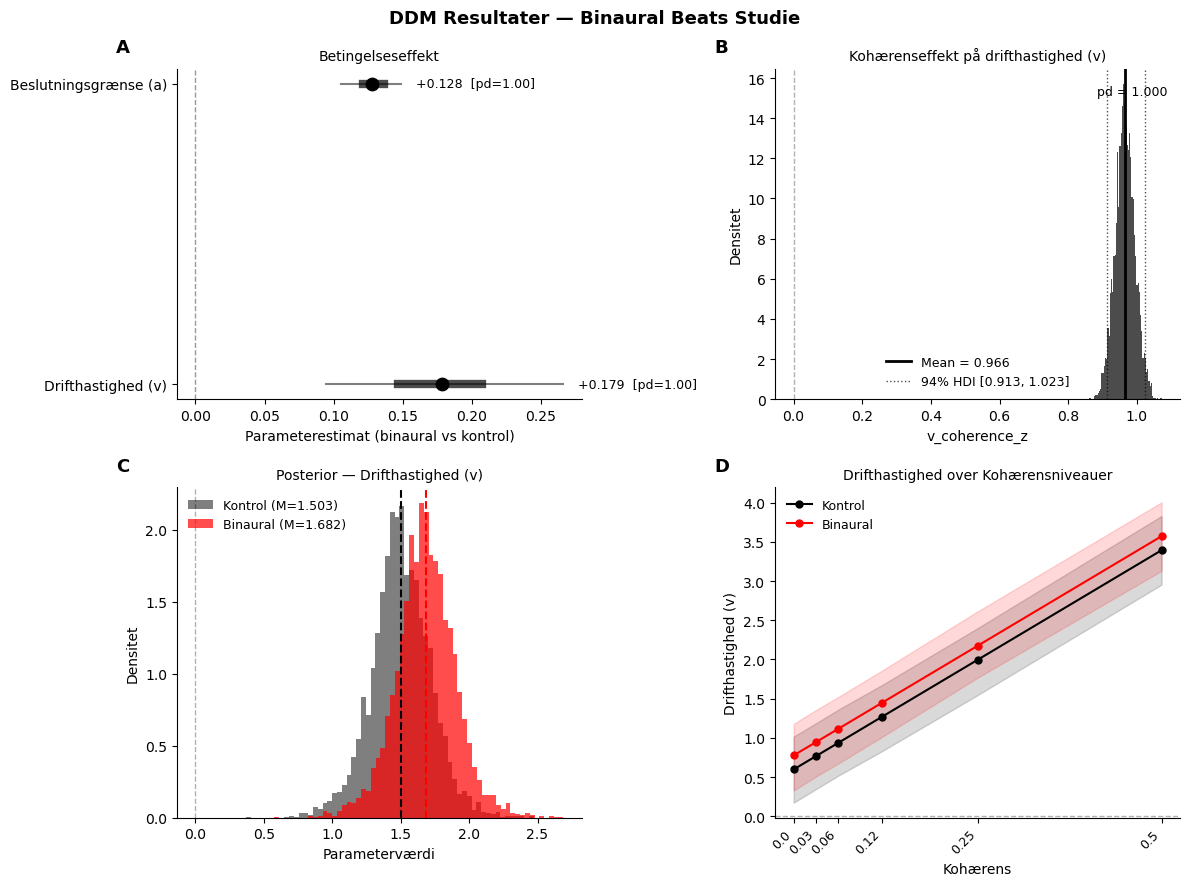

In [46]:
def plot_ddm_rstyle(idata, raw_df_hssm):
    
    coh_levels = sorted(raw_df_hssm["coherence"].unique())
    coh_z_vals = (np.array(coh_levels) - raw_df_hssm["coherence"].mean()) / raw_df_hssm["coherence"].std()
    conditions = ["binaural", "control"]
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    
    # ── 1. Forest plot — condition effects (top left) ─────────────────────
    ax = axes[0, 0]
    condition_vars = ["v_condition", "a_condition"]
    labels = ["Drifthastighed (v)", "Beslutningsgrænse (a)"]
    
    for i, (var, label) in enumerate(zip(condition_vars, labels)):
        s     = idata.posterior[var].values.flatten()
        mean  = float(s.mean())
        hdi94 = az.hdi(s, hdi_prob=0.94)
        hdi50 = az.hdi(s, hdi_prob=0.50)
        prob_dir = max(np.mean(s > 0), np.mean(s < 0))
        
        ax.plot([hdi94[0], hdi94[1]], [i, i],
                color="black", linewidth=1.5, alpha=0.5)
        ax.plot([hdi50[0], hdi50[1]], [i, i],
                color="black", linewidth=6, alpha=0.7)
        ax.scatter(mean, i, color="black", s=80, zorder=5)
        ax.text(hdi94[1] + 0.005, i,
                f"  {mean:+.3f}  [pd={prob_dir:.2f}]",
                va="center", fontsize=9, color="black")
    
    ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.4)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel("Parameterestimat (binaural vs kontrol)", fontsize=10)
    ax.set_title("Betingelseseffekt", fontsize=10)
    ax.text(-0.15, 1.05, "A", transform=ax.transAxes,
            fontsize=13, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    
    # ── 2. Coherence posterior (top right) ────────────────────────────────
    ax = axes[0, 1]
    s     = idata.posterior["v_coherence_z"].values.flatten()
    mean  = float(s.mean())
    hdi94 = az.hdi(s, hdi_prob=0.94)
    prob_dir = max(np.mean(s > 0), np.mean(s < 0))
    
    ax.hist(s, bins=60, density=True, color="black", alpha=0.7, edgecolor="none")
    ax.axvline(mean,     color="black", linewidth=2,
               label=f"Mean = {mean:.3f}")
    ax.axvline(hdi94[0], color="black", linewidth=1, linestyle=":", alpha=0.7)
    ax.axvline(hdi94[1], color="black", linewidth=1, linestyle=":",  alpha=0.7,
               label=f"94% HDI [{hdi94[0]:.3f}, {hdi94[1]:.3f}]")
    ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.3)
    ax.text(0.97, 0.95, f"pd = {prob_dir:.3f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9)
    ax.set_title("Kohærenseffekt på drifthastighed (v)", fontsize=10)
    ax.set_xlabel("v_coherence_z", fontsize=10)
    ax.set_ylabel("Densitet", fontsize=10)
    ax.legend(frameon=False, fontsize=9)
    ax.text(-0.15, 1.05, "B", transform=ax.transAxes,
            fontsize=13, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    
    # ── 3. Binaural vs control posteriors (bottom left) ───────────────────
    ax = axes[1, 0]
    control  = idata.posterior["v_Intercept"].values.flatten()
    binaural = control + idata.posterior["v_condition"].values.flatten()
    
    for samples, label, alpha in [
        (control,  "Kontrol",  0.5),
        (binaural, "Binaural", 0.7),
    ]:
        mean = float(samples.mean())
        ax.hist(samples, bins=60, density=True, alpha=alpha,
                label=f"{label} (M={mean:.3f})",
                color="black" if label=="Kontrol" else "red",
                edgecolor="none")
        ax.axvline(mean,
                   color="black" if label=="Kontrol" else "red",
                   linewidth=1.5, linestyle="--")
    
    ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.3)
    ax.set_title("Posterior — Drifthastighed (v)", fontsize=10)
    ax.set_xlabel("Parameterværdi", fontsize=10)
    ax.set_ylabel("Densitet", fontsize=10)
    ax.legend(frameon=False, fontsize=9)
    ax.text(-0.15, 1.05, "C", transform=ax.transAxes,
            fontsize=13, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    
    # ── 4. Coherence regression lines (bottom right) ──────────────────────
    ax = axes[1, 1]
    
    intercept = idata.posterior["v_Intercept"].values.flatten()
    cond_coef = idata.posterior["v_condition"].values.flatten()
    coh_coef  = idata.posterior["v_coherence_z"].values.flatten()
    
    for cond_val, label, color in [
        (0, "Kontrol",  "black"),
        (1, "Binaural", "red"),
    ]:
        means, lo, hi = [], [], []
        for cz in coh_z_vals:
            predicted = intercept + cond_val * cond_coef + coh_coef * cz
            hdi_vals  = az.hdi(predicted, hdi_prob=0.94)
            means.append(float(predicted.mean()))
            lo.append(float(hdi_vals[0]))
            hi.append(float(hdi_vals[1]))
        
        ax.plot(coh_levels, means,
               color=color, linewidth=1.5,
               marker="o", markersize=5, label=label)
        ax.fill_between(coh_levels, lo, hi,
                       color=color, alpha=0.15)
    
    ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.3)
    ax.set_xticks(coh_levels)
    ax.set_xticklabels([str(c) for c in coh_levels],
                       rotation=45, ha="right", fontsize=9)
    ax.set_xlabel("Kohærens", fontsize=10)
    ax.set_ylabel("Drifthastighed (v)", fontsize=10)
    ax.set_title("Drifthastighed over Kohærensniveauer", fontsize=10)
    ax.legend(frameon=False, fontsize=9)
    ax.text(-0.15, 1.05, "D", transform=ax.transAxes,
            fontsize=13, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    
    plt.suptitle("DDM Resultater — Binaural Beats Studie",
                 fontweight="bold", fontsize=13)
    plt.tight_layout()
    plt.savefig("figures/ddm_rstyle.pdf", bbox_inches="tight", dpi=300)
    plt.show()

plot_ddm_rstyle(idata_all, raw_df_hssm)

[0.5989156481511384] [np.float64(0.0), np.float64(0.03), np.float64(0.06), np.float64(0.12), np.float64(0.25), np.float64(0.5)]
[0.5989156481511384, 0.766556853184867] [np.float64(0.0), np.float64(0.03), np.float64(0.06), np.float64(0.12), np.float64(0.25), np.float64(0.5)]
[0.5989156481511384, 0.766556853184867, 0.9341980582185954] [np.float64(0.0), np.float64(0.03), np.float64(0.06), np.float64(0.12), np.float64(0.25), np.float64(0.5)]
[0.5989156481511384, 0.766556853184867, 0.9341980582185954, 1.2694804682860528] [np.float64(0.0), np.float64(0.03), np.float64(0.06), np.float64(0.12), np.float64(0.25), np.float64(0.5)]
[0.5989156481511384, 0.766556853184867, 0.9341980582185954, 1.2694804682860528, 1.9959256900988764] [np.float64(0.0), np.float64(0.03), np.float64(0.06), np.float64(0.12), np.float64(0.25), np.float64(0.5)]
[0.5989156481511384, 0.766556853184867, 0.9341980582185954, 1.2694804682860528, 1.9959256900988764, 3.392935732046615] [np.float64(0.0), np.float64(0.03), np.float6

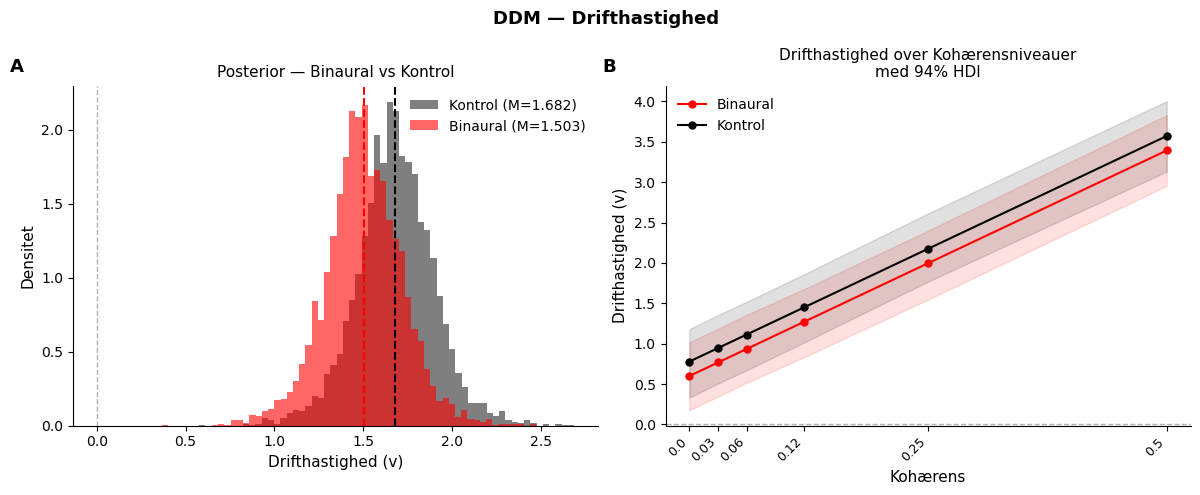

In [66]:
def plot_ddm_main(idata, raw_df_hssm):
    
    coh_levels = sorted(raw_df_hssm["coherence"].unique())
    coh_z_vals = (np.array(coh_levels) - raw_df_hssm["coherence"].mean()) / raw_df_hssm["coherence"].std()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # ── A. Posterior distributions binaural vs control ────────────────────
    ax = axes[0]
    binaural  = idata.posterior["v_Intercept"].values.flatten()
    control = binaural + idata.posterior["v_condition"].values.flatten()
    
    for samples, label, color, alpha in [
        (control,  "Kontrol",  "black", 0.5),
        (binaural, "Binaural", "red",   0.6),
    ]:
        mean = float(samples.mean())
        ax.hist(samples, bins=60, density=True, alpha=alpha,
                label=f"{label} (M={mean:.3f})",
                color=color, edgecolor="none")
        ax.axvline(mean, color=color, linewidth=1.5, linestyle="--")
    
    ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.3)
    ax.set_xlabel("Drifthastighed (v)", fontsize=11)
    ax.set_ylabel("Densitet", fontsize=11)
    ax.set_title("Posterior — Binaural vs Kontrol", fontsize=11)
    ax.legend(frameon=False, fontsize=10)
    ax.text(-0.12, 1.04, "A", transform=ax.transAxes,
            fontsize=13, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    
    # ── B. Coherence regression lines ─────────────────────────────────────
    ax = axes[1]
    
    intercept = idata.posterior["v_Intercept"].values.flatten()
    cond_coef = idata.posterior["v_condition"].values.flatten()
    coh_coef  = idata.posterior["v_coherence_z"].values.flatten()
    
    for cond_val, label, color in [
        (0, "Binaural",  "red"),
        (1, "Kontrol", "black"),
    ]:
        means, lo, hi = [], [], []
        for cz in coh_z_vals:
            predicted = intercept + cond_val * cond_coef + coh_coef * cz

            hdi_vals  = az.hdi(predicted, hdi_prob=0.94)
            means.append(float(predicted.mean()))
            print(means, coh_levels)
            lo.append(float(hdi_vals[0]))
            hi.append(float(hdi_vals[1]))
        
        ax.plot(coh_levels, means,
               color=color, linewidth=1.5,
               marker="o", markersize=5, label=label)
        ax.fill_between(coh_levels, lo, hi, color=color, alpha=0.12)
    
    ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.3)
    ax.set_xticks(coh_levels)
    ax.set_xticklabels([str(c) for c in coh_levels],
                       rotation=45, ha="right", fontsize=9)
    ax.set_xlabel("Kohærens", fontsize=11)
    ax.set_ylabel("Drifthastighed (v)", fontsize=11)
    ax.set_title("Drifthastighed over Kohærensniveauer\nmed 94% HDI", fontsize=11)
    ax.legend(frameon=False, fontsize=10)
    ax.text(-0.12, 1.04, "B", transform=ax.transAxes,
            fontsize=13, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    
    plt.suptitle("DDM — Drifthastighed", fontweight="bold", fontsize=13)
    plt.tight_layout()
    plt.savefig("figures/ddm_main.pdf", bbox_inches="tight", dpi=300)
    plt.show()

plot_ddm_main(idata_all, raw_df_hssm)

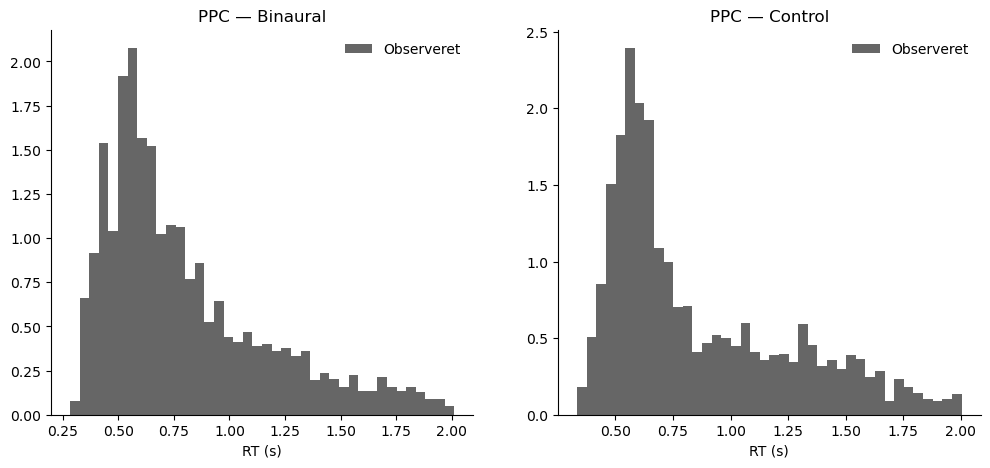

In [54]:
# Generer posterior predictive samples
ppc = model_all.sample_posterior_predictive(idata_all)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cond in zip(axes, ["binaural", "control"]):
    obs = raw_df_hssm[raw_df_hssm["condition"]==cond]["rt"]
    ax.hist(obs, bins=40, density=True, alpha=0.6,
            color="black", label="Observeret", edgecolor="none")
    ax.set_title(f"PPC — {cond.capitalize()}")
    ax.set_xlabel("RT (s)")
    ax.legend(frameon=False)
    ax.spines[["top","right"]].set_visible(False)
plt.savefig("figures/ppc.pdf", bbox_inches="tight", dpi=300)

In [58]:
print(idata_all.posterior_predictive)
print(list(idata_all.posterior_predictive.data_vars))

<xarray.Dataset> Size: 302MB
Dimensions:          (chain: 4, draw: 1000, __obs__: 4724, rt,response_dim: 2)
Coordinates:
  * chain            (chain) int64 32B 0 1 2 3
  * draw             (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
  * __obs__          (__obs__) int64 38kB 0 1 2 3 4 ... 4719 4720 4721 4722 4723
  * rt,response_dim  (rt,response_dim) int64 16B 0 1
Data variables:
    rt,response      (chain, draw, __obs__, rt,response_dim) float64 302MB 0....
Attributes:
    modeling_interface:          bambi
    modeling_interface_version:  0.17.2
['rt,response']


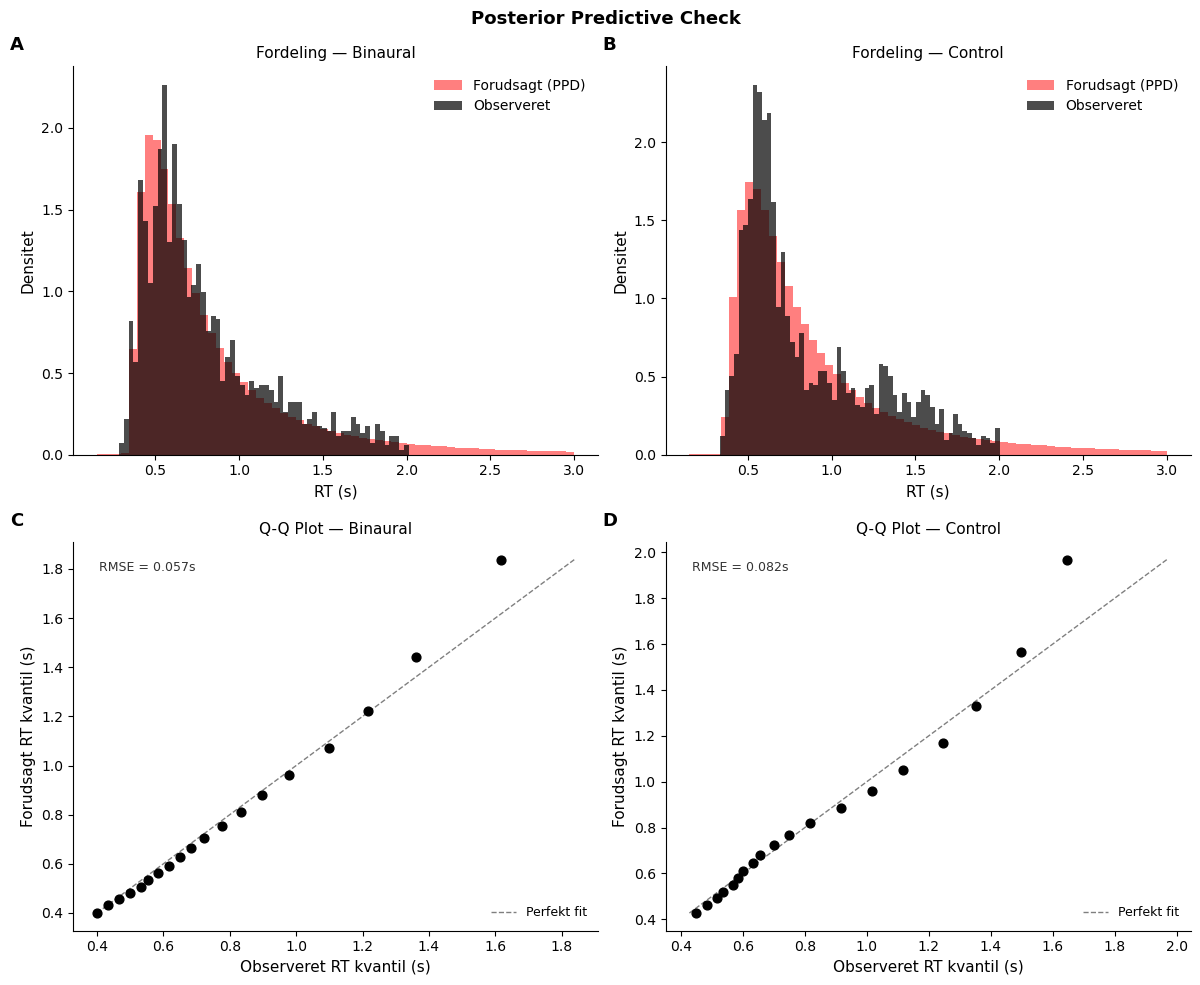

In [63]:
def plot_ppc_full(idata, raw_df_hssm):
    
    ppc_samples = idata.posterior_predictive["rt,response"].values
    conditions  = raw_df_hssm["condition"].values
    quantiles   = np.arange(0.05, 1.0, 0.05)
    
    obs_indices_binaural = np.where(conditions == "binaural")[0]
    obs_indices_control  = np.where(conditions == "control")[0]
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    for col, (cond, obs_idx) in enumerate(zip(
        ["binaural", "control"],
        [obs_indices_binaural, obs_indices_control]
    )):
        obs_rt  = raw_df_hssm[raw_df_hssm["condition"] == cond]["rt"].values
        pred_rt = ppc_samples[:, :, obs_idx, 0].flatten()
        pred_rt = pred_rt[(pred_rt > 0.15) & (pred_rt < 3.0)]
        
        # ── Top row: distributions ────────────────────────────────────────
        ax = axes[0, col]
        
        ax.hist(pred_rt, bins=60, density=True, alpha=0.5,
                color="red", edgecolor="none", label="Forudsagt (PPD)")
        ax.hist(obs_rt,  bins=60, density=True, alpha=0.7,
                color="black", edgecolor="none", label="Observeret")
        
        ax.set_xlabel("RT (s)", fontsize=11)
        ax.set_ylabel("Densitet", fontsize=11)
        ax.set_title(f"Fordeling — {cond.capitalize()}", fontsize=11)
        ax.legend(frameon=False, fontsize=10)
        ax.text(-0.12, 1.04, "A" if col==0 else "B",
                transform=ax.transAxes, fontsize=13, fontweight="bold")
        ax.spines[["top", "right"]].set_visible(False)
        
        # ── Bottom row: Q-Q plot ──────────────────────────────────────────
        ax = axes[1, col]
        
        obs_qs  = [np.quantile(obs_rt,  q) for q in quantiles]
        pred_qs = [np.quantile(pred_rt, q) for q in quantiles]
        rmse    = np.sqrt(np.mean([(o-p)**2 for o,p in zip(obs_qs, pred_qs)]))
        
        min_val = min(min(obs_qs), min(pred_qs))
        max_val = max(max(obs_qs), max(pred_qs))
        
        ax.plot([min_val, max_val], [min_val, max_val],
                color="black", linewidth=1, linestyle="--",
                alpha=0.5, label="Perfekt fit")
        ax.scatter(obs_qs, pred_qs, color="black", s=40, zorder=5)
        
        ax.text(0.05, 0.95, f"RMSE = {rmse:.3f}s",
                transform=ax.transAxes, fontsize=9,
                va="top", color="#333")
        
        ax.set_xlabel("Observeret RT kvantil (s)", fontsize=11)
        ax.set_ylabel("Forudsagt RT kvantil (s)", fontsize=11)
        ax.set_title(f"Q-Q Plot — {cond.capitalize()}", fontsize=11)
        ax.legend(frameon=False, fontsize=9)
        ax.text(-0.12, 1.04, "C" if col==0 else "D",
                transform=ax.transAxes, fontsize=13, fontweight="bold")
        ax.spines[["top", "right"]].set_visible(False)
    
    plt.suptitle("Posterior Predictive Check", fontweight="bold", fontsize=13)
    plt.tight_layout()
    plt.savefig("figures/ppc_full.pdf", bbox_inches="tight", dpi=300)
    plt.show()

plot_ppc_full(idata_all, raw_df_hssm)

In [55]:
def plot_ddm_full(idata, raw_df_hssm):
    
    coh_levels = sorted(raw_df_hssm["coherence"].unique())
    coh_z_vals = (np.array(coh_levels) - raw_df_hssm["coherence"].mean()) / raw_df_hssm["coherence"].std()
    participants = list(idata.posterior["v_1|participant_id"].coords["v_1|participant_id_dim_0"].values)
    
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    
    # ── A. Posterior v — binaural vs control ──────────────────────────────
    ax = axes[0, 0]
    binaural = idata.posterior["v_Intercept"].values.flatten()
    control  = binaural + idata.posterior["v_condition[control]"].values.flatten()
    
    for samples, label, color, alpha in [
        (binaural, "Binaural", "red",   0.6),
        (control,  "Kontrol",  "black", 0.5),
    ]:
        mean = float(samples.mean())
        ax.hist(samples, bins=60, density=True, alpha=alpha,
                label=f"{label} (M={mean:.3f})",
                color=color, edgecolor="none")
        ax.axvline(mean, color=color, linewidth=1.5, linestyle="--")
    
    ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.3)
    ax.set_xlabel("Drifthastighed (v)", fontsize=11)
    ax.set_ylabel("Densitet", fontsize=11)
    ax.set_title("Posterior — Drifthastighed\nBinaural vs Kontrol", fontsize=11)
    ax.legend(frameon=False, fontsize=10)
    ax.text(-0.12, 1.04, "A", transform=ax.transAxes, fontsize=13, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    
    # ── B. Coherence regression lines ─────────────────────────────────────
    ax = axes[0, 1]
    intercept = idata.posterior["v_Intercept"].values.flatten()
    cond_coef = idata.posterior["v_condition[control]"].values.flatten()
    coh_coef  = idata.posterior["v_coherence_z"].values.flatten()
    
    for cond_val, label, color in [
        (0, "Binaural", "red"),
        (1, "Kontrol",  "black"),
    ]:
        means, lo, hi = [], [], []
        for cz in coh_z_vals:
            predicted = intercept + cond_val * cond_coef + coh_coef * cz
            hdi_vals  = az.hdi(predicted, hdi_prob=0.94)
            means.append(float(predicted.mean()))
            lo.append(float(hdi_vals[0]))
            hi.append(float(hdi_vals[1]))
        
        ax.plot(coh_levels, means, color=color, linewidth=1.5,
                marker="o", markersize=5, label=label)
        ax.fill_between(coh_levels, lo, hi, color=color, alpha=0.12)
    
    ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.3)
    ax.set_xticks(coh_levels)
    ax.set_xticklabels([str(c) for c in coh_levels], rotation=45, ha="right", fontsize=9)
    ax.set_xlabel("Kohærens", fontsize=11)
    ax.set_ylabel("Drifthastighed (v)", fontsize=11)
    ax.set_title("Drifthastighed over Kohærensniveauer\nmed 94% HDI", fontsize=11)
    ax.legend(frameon=False, fontsize=10)
    ax.text(-0.12, 1.04, "B", transform=ax.transAxes, fontsize=13, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    
    # ── C. Posterior a — binaural vs control ──────────────────────────────
    ax = axes[1, 0]
    binaural_a = idata.posterior["a_Intercept"].values.flatten()
    control_a  = binaural_a + idata.posterior["a_condition[control]"].values.flatten()
    
    for samples, label, color, alpha in [
        (binaural_a, "Binaural", "red",   0.6),
        (control_a,  "Kontrol",  "black", 0.5),
    ]:
        mean = float(samples.mean())
        ax.hist(samples, bins=60, density=True, alpha=alpha,
                label=f"{label} (M={mean:.3f})",
                color=color, edgecolor="none")
        ax.axvline(mean, color=color, linewidth=1.5, linestyle="--")
    
    ax.set_xlabel("Beslutningsgrænse (a)", fontsize=11)
    ax.set_ylabel("Densitet", fontsize=11)
    ax.set_title("Posterior — Beslutningsgrænse\nBinaural vs Kontrol", fontsize=11)
    ax.legend(frameon=False, fontsize=10)
    ax.text(-0.12, 1.04, "C", transform=ax.transAxes, fontsize=13, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    
    # ── D. Individual participant estimates from idata ────────────────────
    ax = axes[1, 1]
    offset = 0.2
    n = len(participants)
    
    intercept  = idata.posterior["v_Intercept"].values.flatten()
    cond_coef  = idata.posterior["v_condition[control]"].values.flatten()
    re_samples = idata.posterior["v_1|participant_id"].values  # (chains, draws, participants)
    
    for i, pid in enumerate(participants):
        re = re_samples[:, :, i].flatten()
        
        # Binaural = intercept + random effect
        binaural_v = intercept + re
        # Control = intercept + condition + random effect
        control_v  = intercept + cond_coef + re
        
        for samples, label, color, off in [
            (binaural_v, "Binaural", "red",   +offset),
            (control_v,  "Kontrol",  "black", -offset),
        ]:
            mean  = float(samples.mean())
            hdi94 = az.hdi(samples, hdi_prob=0.94)
            
            ax.plot([hdi94[0], hdi94[1]], [i + off, i + off],
                    color=color, linewidth=2, alpha=0.6)
            ax.scatter(mean, i + off, color=color, s=70, zorder=5,
                      label=label if i==0 else "")
        
        # Arrow from binaural to control
        ax.annotate("",
                   xy=(float((intercept + cond_coef + re).mean()), i - offset),
                   xytext=(float((intercept + re).mean()),          i + offset),
                   arrowprops=dict(arrowstyle="->", color="#555",
                                  alpha=0.4, lw=1.2))
    
    ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.3)
    ax.set_yticks(range(n))
    ax.set_yticklabels([p.capitalize() for p in participants], fontsize=10)
    ax.set_xlabel("Drifthastighed (v)", fontsize=11)
    ax.set_title("Individuelle Estimater\nBinaural vs Kontrol med 94% HDI", fontsize=11)
    ax.legend(frameon=False, fontsize=10)
    ax.text(-0.12, 1.04, "D", transform=ax.transAxes, fontsize=13, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    
    plt.suptitle("DDM Resultater — Binaural Beats Studie",
                 fontweight="bold", fontsize=14)
    plt.tight_layout()
    plt.savefig("figures/ddm_full.pdf", bbox_inches="tight", dpi=300)
    plt.show()

plot_ddm_full(idata_all, raw_df_hssm)

KeyError: 'v_1|participant_id_dim_0'